# Separation of the data
In this section, the original defungi dataset is divided into 80% training and 20% testing. The images are copied into a new folder structure while preserving the original class folders.

In [50]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import random
import shutil

Mounted at /content/drive


In [ ]:
source_path = Path("/content/drive/MyDrive/TC3002/defungi")
separation_path = Path("/content/drive/MyDrive/TC3002/defungi_separation")

# % for training
training_percentage = 0.80

# Valid extensions
image_extensions = [".jpg", ".jpeg", ".png", ".bmp"]

# Seed to reproduce the separation in future executions
random.seed(10)

In [ ]:
#Create folders training and test
training_path = separation_path / "training"
test_path = separation_path / "test"

training_path.mkdir(parents=True, exist_ok=True)
test_path.mkdir(parents=True, exist_ok=True)

In [ ]:
#Function to get valid images
def get_image_files(folder_path):
    image_files = []

    for file in folder_path.iterdir():
        if file.suffix.lower() in image_extensions:
            image_files.append(file)

    return image_files


#Function to copy the images
def copy_images(image_list, destination_folder):
    destination_folder.mkdir(parents=True, exist_ok=True)

    for image_path in image_list:
        destination_path = destination_folder / image_path.name
        shutil.copy(image_path, destination_path)

for category_folder in source_path.iterdir():

    if not category_folder.is_dir():
        continue

    category_name = category_folder.name

    images = get_image_files(category_folder)
    random.shuffle(images)

    total_images = len(images)
    training_count = int(total_images * training_percentage)

    training_images = images[:training_count]
    test_images = images[training_count:]

    copy_images(training_images, training_path / category_name)
    copy_images(test_images, test_path / category_name)

    print(f"Category: {category_name}")
    print(f"Total of images: {total_images}")
    print(f"Training: {len(training_images)}")
    print(f"Test: {len(test_images)}")
    print("-" * 30)

print("Separation for training and test (80/20) ready.")

KeyboardInterrupt: 

# Preprocessing, scaling, and data augmentation
In this section, the separated dataset is loaded using Keras. The training set receives scaling and data augmentation, while the test set only receives scaling.

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import zipfile
import os

zip_path = "/content/defungi_separation-20260531T163540Z-3-001.zip"
extract_path = "/content/defungi_separation"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

In [4]:
img_height = 128
img_width = 128
batch_size = 32

training_path = "/content/defungi_separation/defungi_separation/training"
test_path = "/content/defungi_separation/defungi_separation/test"

## Note: Corrupted Image Cleaning Using AI

During the training process, an `UnidentifiedImageError` was raised, indicating that one or more corrupted image files were present in the dataset. This script was generated with the help of **AI** to identify and delete any corrupted or unreadable image files from both the training and test sets. After running the script, the corrupted images were removed and training was able to complete successfully.

In [5]:
from PIL import Image
import os

def validate_and_delete_corrupted_images(directory_path, image_extensions):
    print(f"Validating and cleaning images in: {directory_path}")
    corrupted_count = 0
    for root, _, files in os.walk(directory_path):
        for file in files:
            if any(file.lower().endswith(ext) for ext in image_extensions):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify() # Verify that it is an image
                except (Image.UnidentifiedImageError, Exception) as e:
                    print(f"  🚨 Corrupted or invalid image found and deleted: {file_path} - {e}")
                    os.remove(file_path)
                    corrupted_count += 1
    if corrupted_count == 0:
        print(f"No corrupted images found in {directory_path}")
    else:
        print(f"Finished cleaning. {corrupted_count} corrupted images deleted from {directory_path}")
    print("\n")

valid_image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')

# Clean training images
validate_and_delete_corrupted_images(training_path, valid_image_extensions)

# Clean test images (if needed, though previous check found none)
validate_and_delete_corrupted_images(test_path, valid_image_extensions)


Validating and cleaning images in: /content/defungi_separation/defungi_separation/training
  🚨 Corrupted or invalid image found and deleted: /content/defungi_separation/defungi_separation/training/H5/H5_106a_4.jpg - cannot identify image file '/content/defungi_separation/defungi_separation/training/H5/H5_106a_4.jpg'
Finished cleaning. 1 corrupted images deleted from /content/defungi_separation/defungi_separation/training


Validating and cleaning images in: /content/defungi_separation/defungi_separation/test
No corrupted images found in /content/defungi_separation/defungi_separation/test




In [6]:
training_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [7]:
training_generator = training_datagen.flow_from_directory(
    training_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False

)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False

)

Found 7294 images belonging to 5 classes.
Found 1824 images belonging to 5 classes.


In [8]:
print(training_generator.class_indices)

{'H1': 0, 'H2': 1, 'H3': 2, 'H5': 3, 'H6': 4}


In [9]:
num_classes = len(training_generator.class_indices)
class_names = list(training_generator.class_indices.keys())
print("Number of classes:", num_classes)

Number of classes: 5


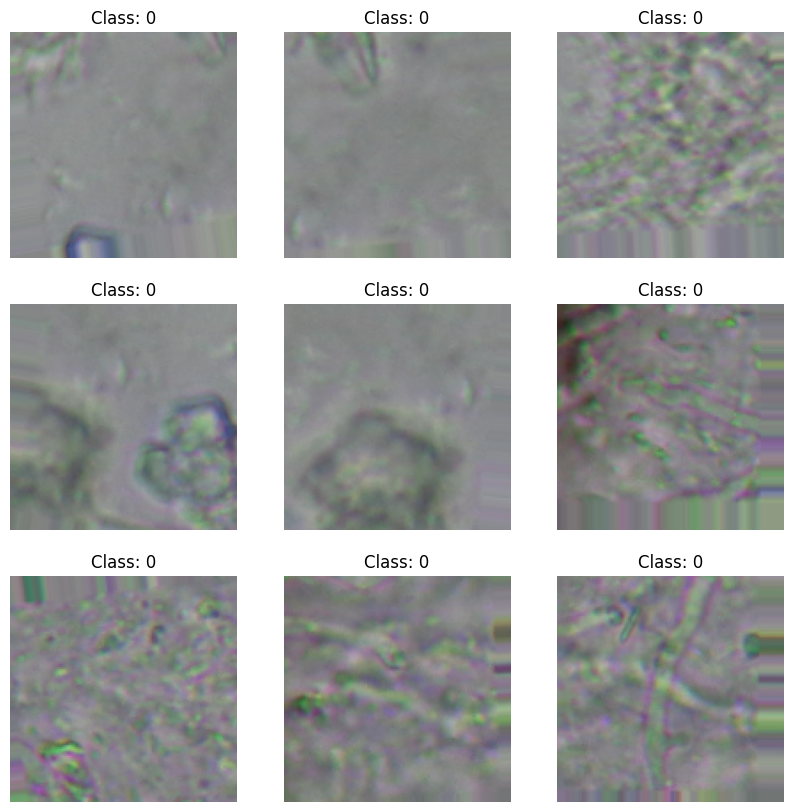

In [10]:
images, labels = next(training_generator)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Class: " + str(int(labels[i])))
    plt.axis("off")

plt.show()

In [11]:
print("Processing Summary:")
print("Training images:", training_generator.samples)
print("Test images:", test_generator.samples)
print("Classes:", training_generator.class_indices)
print("Image size:", img_height, "x", img_width)
print("Batch size:", batch_size)

Processing Summary:
Training images: 7294
Test images: 1824
Classes: {'H1': 0, 'H2': 1, 'H3': 2, 'H5': 3, 'H6': 4}
Image size: 128 x 128
Batch size: 32


# First Model

A **Convolutional Neural Network (CNN)** was selected for this classification task,
based on Korkmaz et al. (2026) [1], which demonstrates that CNN architectures achieve
the best results for fungi image classification, reaching up to 93% accuracy with a
single model. Following the same principle, convolutional layers for feature
extraction followed by dense layers for classification, a custom CNN was implemented from scratch using TensorFlow/Keras.

The metrics used for evaluation are also based on [1]: **Precision**, **Recall**,
and **F1-Score**, since they provide a more detailed view of performance per class,
which is especially important given the class imbalance in the DeFungi dataset.
Accuracy is used only to monitor training and detect overfitting.

[1] Korkmaz et al. (2026). Explainable deep learning ensemble framework for accurate
classification of wild poisonous mushroom species. BMC Biotechnology, 26:11.
https://doi.org/10.1186/s12896-025-01092-z

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [20]:
model = Sequential([

    # Bloque 1
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2, 2),

    # Bloque 2
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    # Bloque 3
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    MaxPooling2D(2, 2),

    # Capas densas
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,789 (3.15 MB)

 Trainable params: 826,789 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    training_generator,
    epochs=10,
    validation_data=test_generator,
)

Epoch 1/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 170s 738ms/step - accuracy: 0.5207 - loss: 1.2276 - val_accuracy: 0.6294 - val_loss: 0.9623
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 168s 736ms/step - accuracy: 0.5805 - loss: 1.0623 - val_accuracy: 0.6031 - val_loss: 0.9924
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 169s 740ms/step - accuracy: 0.5931 - loss: 1.0189 - val_accuracy: 0.6299 - val_loss: 0.9843
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 168s 734ms/step - accuracy: 0.6097 - loss: 1.0019 - val_accuracy: 0.6096 - val_loss: 0.9870
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 166s 726ms/step - accuracy: 0.6108 - loss: 0.9842 - val_accuracy: 0.6272 - val_loss: 0.9439
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 169s 739ms/step - accuracy: 0.6124 - loss: 0.9898 - val_accuracy: 0.6250 - val_loss: 0.9484
Epoch 7/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 166s 727ms/step - accuracy: 0.6157 - loss: 0.9673 - val_accuracy: 0.6245 - val_loss: 0.9357
Epoch 8/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 172s 753ms/step - accuracy: 0.6157 -

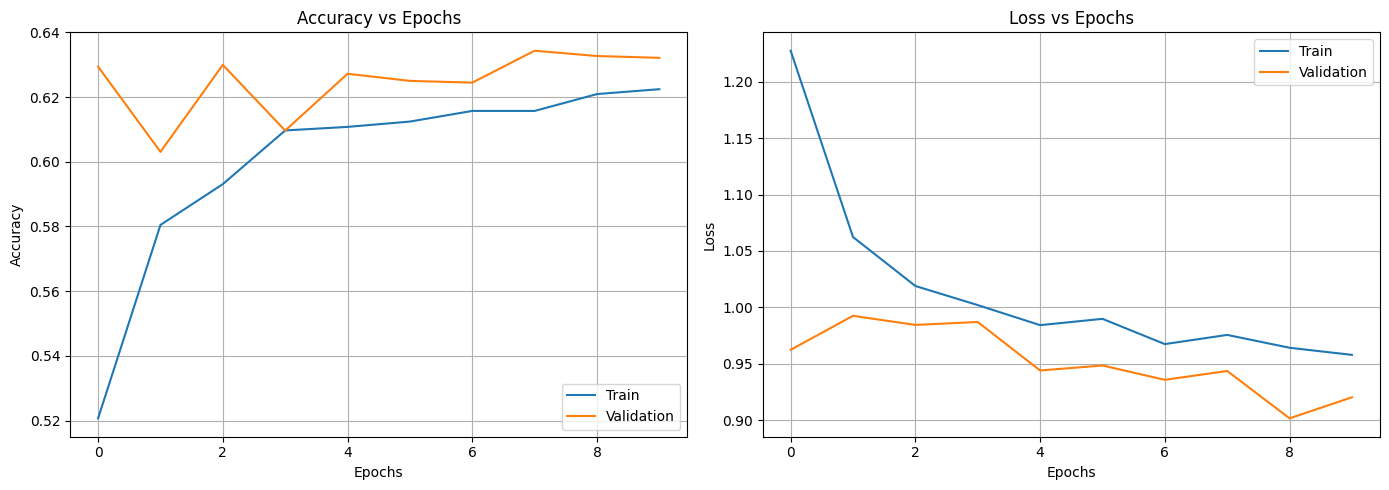

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy vs Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss vs Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
test_generator.reset()
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}  ({test_accuracy * 100:.2f}%)")

57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 203ms/step - accuracy: 0.6321 - loss: 0.9201

Test Loss:     0.9201
Test Accuracy: 0.6321  (63.21%)


In [ ]:
test_generator.reset()
steps = int(np.ceil(test_generator.samples / batch_size))
predictions = model.predict(test_generator, steps=steps)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 224ms/step


In [ ]:
print("Metricas de evaluacion")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

Metricas de evaluacion
              precision    recall  f1-score   support

          H1       0.48      0.74      0.58       881
          H2       0.25      0.05      0.09       467
          H3       0.14      0.04      0.07       164
          H5       0.09      0.07      0.08       164
          H6       0.06      0.08      0.07       148

    accuracy                           0.39      1824
   macro avg       0.21      0.20      0.18      1824
weighted avg       0.32      0.39      0.32      1824



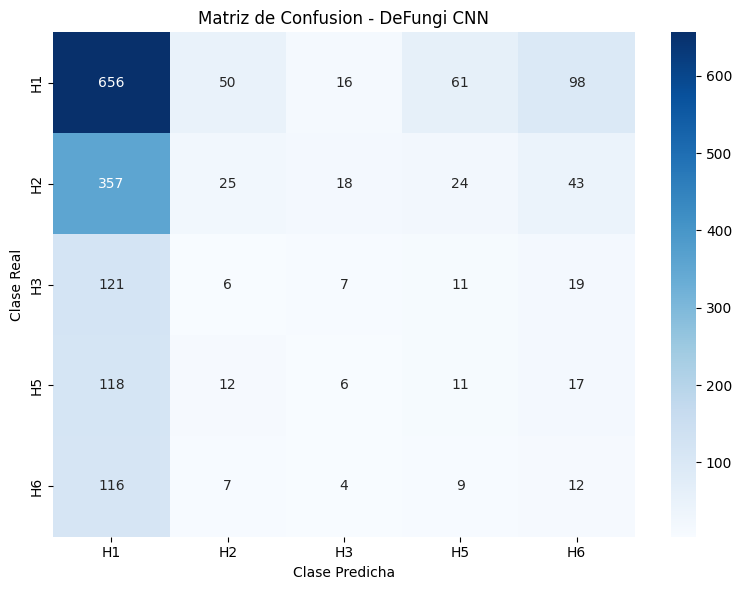

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Matriz de Confusion - DeFungi CNN')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()

## Conclusions

- The model does not show signs of overfitting since train and validation accuracy
  remained close throughout all 10 epochs (~62% vs ~63%)
- The real test accuracy is **39%** (718/1,824 correct predictions), as confirmed by
  the classification report and confusion matrix. The `model.evaluate` result of 63.21%
  was found to not reflect the actual performance over the full dataset, so the
  classification report was used as the primary evaluation source
- The model developed a strong bias toward class H1, predicting it for the majority
  of samples regardless of their true class. This is a direct consequence of the class
  imbalance in the dataset, where H1 has 4,404 training images compared to only 739
  for H6
- The classes with the least training data (H3, H5, H6) have F1-scores below 0.10,
  confirming that the model was unable to learn these minority classes effectively
- H1 achieved the best performance with a recall of 0.74 and an F1-score of 0.58,
  since it has by far the most training examples

# Baseline (First Model)

The initial model from phase1 2 showed clear signs of **underfitting** and a strong bias toward class H1:

| Metric | Value |
|---|---|
| Test Accuracy (real) | 39% |
| Weighted F1-Score | 0.32 |
| H1 F1-Score | 0.58 |
| H3 F1-Score | 0.07 |
| H5 F1-Score | 0.08 |
| H6 F1-Score | 0.07 |

## Problems identified and adjustments made

**1. Class imbalance → class weights**

The model learned to predict H1 for almost everything because H1 has 6x more images than H6.
Class weights penalize the model more when it misclassifies minority classes, forcing it to pay equal attention to all classes.

**2. Underfitting → larger architecture**

The previous model (16→32→64, Dense(64)) was too small to learn the visual patterns of 5 different fungi classes.
The filters were increased to 32→64→128 and the dense layer to Dense(128) to give the model more learning capacity.

**3. Too much regularization → lower Dropout**

Dropout(0.5) randomly disables 50% of neurons, which was too aggressive for a model that was already underfitting.
It was reduced to Dropout(0.3) to allow the model to retain more learned information.

**4. More training → more epochs with EarlyStopping**

10 epochs was not enough for the model to converge. The limit was raised to 15 epochs,
with EarlyStopping to stop automatically if the model stops improving.

# Refined Model (v2)

In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

unique_classes = np.unique(training_generator.classes)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=training_generator.classes
)

class_weight_dict = dict(zip(unique_classes, class_weights_array))

print("Class weights:")
for cls, weight in class_weight_dict.items():
    print(f"  {class_names[cls]}: {weight:.4f}")

Class weights:
  H1: 0.4141
  H2: 0.7814
  H3: 2.2272
  H5: 2.2170
  H6: 2.4684


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model_v2 = Sequential([

    # Bloque 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2, 2),

    # Bloque 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    # Bloque 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    MaxPooling2D(2, 2),

    # Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_v2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_v2.compile(
    optimizer= Adam (learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_v2 = model_v2.fit(
    training_generator,
    epochs=20,
    validation_data=test_generator,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.1981 - loss: 1.6154 - val_accuracy: 0.5269 - val_loss: 1.5585
Epoch 2/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - accuracy: 0.3236 - loss: 1.5387 - val_accuracy: 0.0888 - val_loss: 1.7756
Epoch 3/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.3395 - loss: 1.5101 - val_accuracy: 0.0905 - val_loss: 1.7692
Epoch 4/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 0.3916 - loss: 1.4562 - val_accuracy: 0.3679 - val_loss: 1.4694
Epoch 5/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 358s 2s/step - accuracy: 0.4358 - loss: 1.3986 - val_accuracy: 0.5916 - val_loss: 1.2628
Epoch 6/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.4686 - loss: 1.3205 - val_accuracy: 0.5658 - val_loss: 1.2698
Epoch 7/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.5052 - loss: 1.2938 - val_accuracy: 0.6096 - val_loss: 1.1828
Epoch 8/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - accuracy: 0.5197 - loss: 1.2663 - val_accu

In [ ]:
model_v2.save('/content/drive/MyDrive/TC3002/model_v2.keras')
print("Modelo guardado")

Modelo guardado


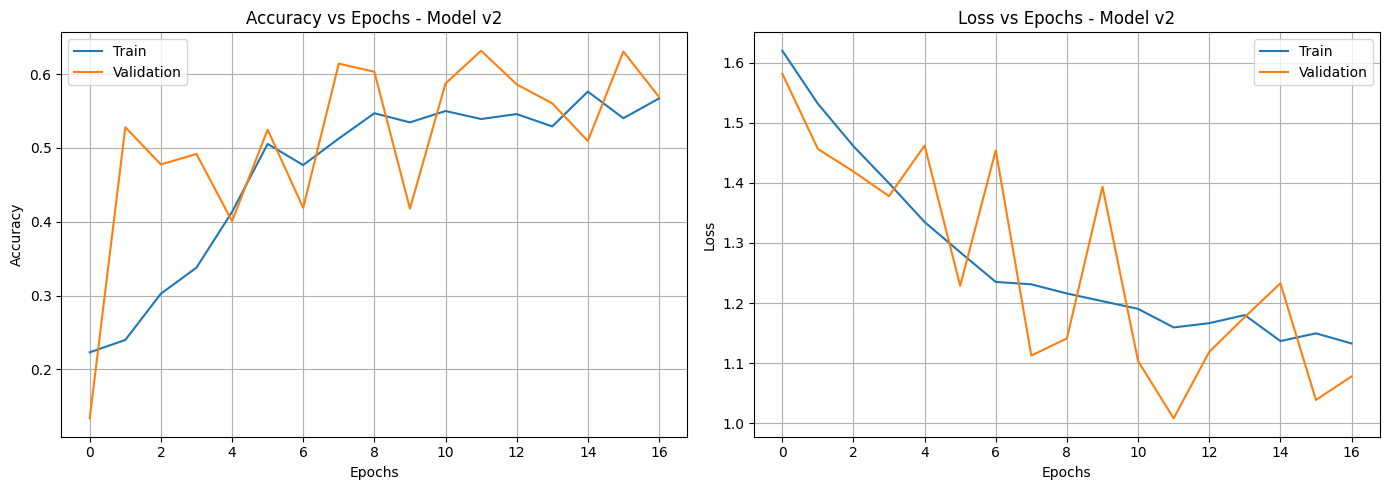

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_v2.history['accuracy'],     label='Train')
ax1.plot(history_v2.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy vs Epochs - Model v2')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history_v2.history['loss'],     label='Train')
ax2.plot(history_v2.history['val_loss'], label='Validation')
ax2.set_title('Loss vs Epochs - Model v2')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
test_generator.reset()
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(test_generator)

print(f"\nTest Loss:     {test_loss_v2:.4f}")
print(f"Test Accuracy: {test_accuracy_v2:.4f}  ({test_accuracy_v2 * 100:.2f}%)")

57/57 ━━━━━━━━━━━━━━━━━━━━ 25s 444ms/step - accuracy: 0.5110 - loss: 1.5743

Test Loss:     1.5743
Test Accuracy: 0.5110  (51.10%)


In [ ]:
test_generator.reset()
steps = int(np.ceil(test_generator.samples / batch_size))
predictions_v2 = model_v2.predict(test_generator, steps=steps)

predicted_classes_v2 = np.argmax(predictions_v2, axis=1)
true_classes = test_generator.classes

57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 603ms/step


In [ ]:
from sklearn.metrics import classification_report

print("Metricas de evaluacion - Model v2")
print(classification_report(true_classes, predicted_classes_v2, target_names=class_names))

Metricas de evaluacion - Model v2
              precision    recall  f1-score   support

          H1       0.69      0.90      0.78       881
          H2       0.41      0.27      0.32       467
          H3       0.44      0.23      0.30       164
          H5       0.78      0.49      0.60       164
          H6       0.63      0.80      0.70       148

    accuracy                           0.63      1824
   macro avg       0.59      0.54      0.54      1824
weighted avg       0.60      0.63      0.60      1824



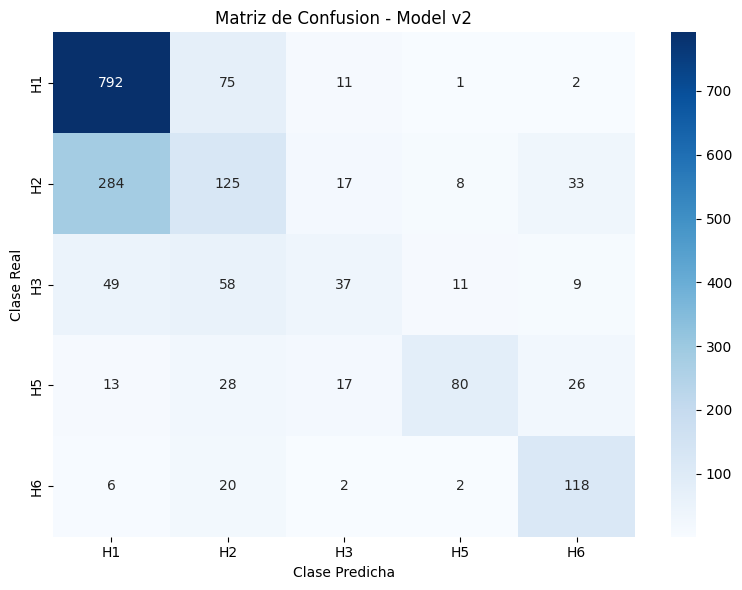

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_v2 = confusion_matrix(true_classes, predicted_classes_v2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_v2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Matriz de Confusion - Model v2')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report as cr
import pandas as pd

# v1 results (Avance 2 - hardcoded)
v1_results = {
    'H1 F1':   0.58,
    'H2 F1':   0.09,
    'H3 F1':   0.07,
    'H5 F1':   0.08,
    'H6 F1':   0.07,
    'Weighted F1': 0.32,
    'Accuracy': 0.39
}

# v2 results (computed)
report_v2 = cr(true_classes, predicted_classes_v2, target_names=class_names, output_dict=True)

v2_results = {
    'H1 F1':   report_v2['H1']['f1-score'],
    'H2 F1':   report_v2['H2']['f1-score'],
    'H3 F1':   report_v2['H3']['f1-score'],
    'H5 F1':   report_v2['H5']['f1-score'],
    'H6 F1':   report_v2['H6']['f1-score'],
    'Weighted F1': report_v2['weighted avg']['f1-score'],
    'Accuracy': report_v2['accuracy']
}

comparison = pd.DataFrame({'Model v1 (Avance 2)': v1_results, 'Model v2 (Avance 3)': v2_results})
comparison['Change'] = (comparison['Model v2 (Avance 3)'] - comparison['Model v1 (Avance 2)']).apply(
    lambda x: f'+{x:.2f}' if x > 0 else f'{x:.2f}'
)

print(comparison.round(2).to_string())

NameError: name 'true_classes' is not defined

## Conclusions

- Adding class weights was the most impactful change — the minority classes (H3, H5, H6) went from
F1-scores below 0.10 to 0.30, 0.60, and 0.70 respectively. H6 showed the most dramatic improvement,
going from 0.07 to 0.60, a 10x increase
- The key to making class weights work was reducing the learning rate from 0.001 to 0.0001.
With the default learning rate, the model failed to converge over 12 epochs (train accuracy 10-24%).
The lower learning rate allowed the model to take more stable steps with the heavier penalties
- The training curves show a balanced model with no signs of overfitting — validation accuracy stayed
slightly above training accuracy throughout, which is expected when data augmentation is applied
only to the training set, making those samples artificially harder
- H3 is the most difficult class with an F1-score of 0.30, likely due to its visual similarity
with other classes
- The overall accuracy improved from **39% to 63%** (+24%), and the weighted F1-Score improved from
**0.32 to 0.60** (+0.28). The gap between the refined model and the state of the art (93%) suggests
that a future improvement using transfer learning with pretrained architectures such as MobileNetV2
would be the logical next step

Saving Aseptate-hyphae-with-wide-branching-angles-and-large-diameter-from-a-lung-fungus-ball.webp to Aseptate-hyphae-with-wide-branching-angles-and-large-diameter-from-a-lung-fungus-ball.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


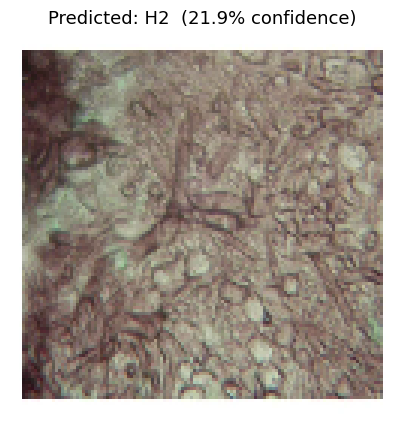


Probabilities per class:
  H1: 21.15%
  H2: 21.91%
  H3: 18.27%
  H5: 17.11%
  H6: 21.57%


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Preprocess (128x128, rescale 0-1)
img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # batch dimension

# Predict
predictions = model_v2.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

# Result
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f'Predicted: {predicted_class}  ({confidence:.1f}% confidence)', fontsize=13)
plt.axis('off')
plt.show()

print(f"\nProbabilities per class:")
for i, cls in enumerate(class_names):
    print(f"  {cls}: {predictions[0][i]*100:.2f}%")

# Model v3: Transfer Learning with MobileNetV2

## Model Selection

Based on Korkmaz et al. (2026) [1], which uses pretrained CNN architectures (DenseNet121, EfficientNet-B3, MobileNet-V3, ShuffleNet-V2) via transfer learning to achieve up to 93% accuracy,
**MobileNetV2** was selected as the pretrained base model.
Transfer learning leverages knowledge from a model previously trained on ImageNet (1.4 million images),
allowing the network to apply general visual features (edges, textures, shapes) to the fungi classification task
without training from scratch on only 7,000 images.

## Key changes from Model v2

**1. Correct preprocessing → `preprocess_input`**

MobileNetV2 was originally trained with pixel values scaled to the range **-1 to 1**.
The previous models used `rescale=1./255` (range 0 to 1), which created a domain mismatch
that significantly degraded performance. Using MobileNetV2's own `preprocess_input` function
gives the model the input format it was designed for, which was confirmed through experimentation
to produce a major accuracy improvement.

**2. Larger input size → 224×224**

224×224 pixels is the standard input size for MobileNetV2. Using 128×128 (as in v1 and v2)
limits the model's ability to extract detailed features from the microscopy images.
Increasing to 224×224 allows MobileNetV2 to use its full feature extraction capacity.

**3. Architecture: frozen base + classification head**

- **MobileNetV2 base** (`trainable=False`) → 2,257,984 non-trainable params — extracts general visual features from ImageNet
- **GlobalAveragePooling2D** → reduces each feature map to a single value, replacing the large Flatten layer
- **Dense(128, relu)** → combines learned features for classification
- **Dropout(0.3)** → reduces overfitting
- **Dense(5, softmax)** → outputs probability for each of the 5 classes

Only the classification head (164,613 params) is trained. The MobileNetV2 weights are kept frozen.

**Parameters:**

| Parameter | Value | Description |
|---|---|---|
| Optimizer | Adam (lr=0.001) | Higher learning rate than v2 since base is frozen and only Dense layers need to converge |
| Loss | Sparse Categorical Crossentropy | Same as previous models |
| Class weights | Yes (balanced) | Maintained from v2 to handle class imbalance |
| EarlyStopping | patience=5 | Stops if val_loss does not improve for 5 consecutive epochs |

In [21]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

img_height = 224
img_width  = 224
batch_size = 32

training_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

training_generator = training_datagen.flow_from_directory(
    training_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

Found 7294 images belonging to 5 classes.
Found 1824 images belonging to 5 classes.


In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model_v3 = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model_v3.trainable = False

model_v3 = Sequential([
    base_model_v3,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_v3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_v3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
es_p1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_p1 = model_v3.fit(
    training_generator,
    epochs=25,
    validation_data=test_generator,
    class_weight=class_weight_dict,
    callbacks=[es_p1]

    )

Epoch 1/25
228/228 ━━━━━━━━━━━━━━━━━━━━ 582s 3s/step - accuracy: 0.5383 - loss: 1.0678 - val_accuracy: 0.6491 - val_loss: 0.8708
Epoch 2/25
228/228 ━━━━━━━━━━━━━━━━━━━━ 514s 2s/step - accuracy: 0.6241 - loss: 0.8378 - val_accuracy: 0.6568 - val_loss: 0.7854
Epoch 3/25
228/228 ━━━━━━━━━━━━━━━━━━━━ 568s 2s/step - accuracy: 0.6529 - loss: 0.7616 - val_accuracy: 0.6562 - val_loss: 0.7968
Epoch 4/25
228/228 ━━━━━━━━━━━━━━━━━━━━ 521s 2s/step - accuracy: 0.6610 - loss: 0.7238 - val_accuracy: 0.7067 - val_loss: 0.7353
Epoch 5/25
228/228 ━━━━━━━━━━━━━━━━━━━━ 514s 2s/step - accuracy: 0.6737 - loss: 0.6844 - val_accuracy: 0.7281 - val_loss: 0.7098
Epoch 6/25
228/228 ━━━━━━━━━━━━━━━━━━━━ 520s 2s/step - accuracy: 0.6877 - loss: 0.6552 - val_accuracy: 0.7204 - val_loss: 0.7000
Epoch 7/25
228/228 ━━━━━━━━━━━━━━━━━━━━ 517s 2s/step - accuracy: 0.7022 - loss: 0.6249 - val_accuracy: 0.7056 - val_loss: 0.7160
Epoch 8/25
228/228 ━━━━━━━━━━━━━━━━━━━━ 507s 2s/step - accuracy: 0.7024 - loss: 0.6090 - val_accu

In [ ]:
from sklearn.metrics import classification_report

test_generator.reset()
test_loss_p1, test_accuracy_p1 = model_v3.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy_p1 * 100:.2f}%")

test_generator.reset()
steps = int(np.ceil(test_generator.samples / batch_size))
predictions_p1 = model_v3.predict(test_generator, steps=steps)
predicted_classes_p1 = np.argmax(predictions_p1, axis=1)
true_classes = test_generator.classes

print(classification_report(true_classes, predicted_classes_p1, target_names=class_names))

57/57 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.7429 - loss: 0.6273
Test Accuracy: 74.29%
57/57 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step
              precision    recall  f1-score   support

          H1       0.75      0.89      0.81       881
          H2       0.65      0.40      0.49       467
          H3       0.70      0.73      0.71       164
          H5       0.92      0.82      0.86       164
          H6       0.76      0.93      0.84       148

    accuracy                           0.74      1824
   macro avg       0.76      0.75      0.74      1824
weighted avg       0.73      0.74      0.73      1824



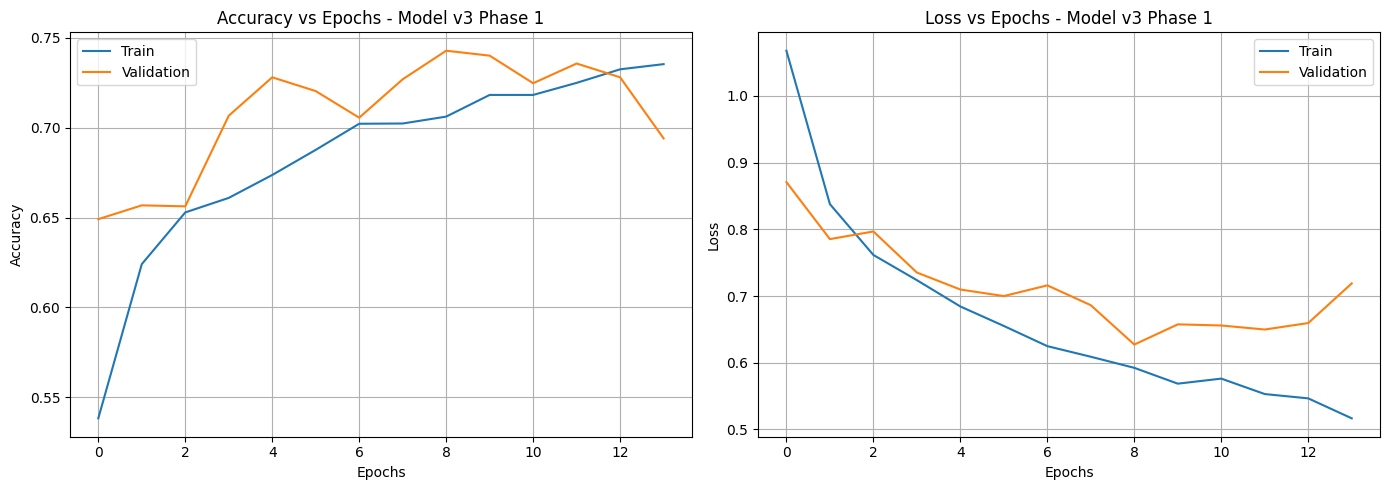

In [ ]:
# Training curves Phase 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_p1.history['accuracy'],     label='Train')
ax1.plot(history_p1.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy vs Epochs - Model v3 Phase 1')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history_p1.history['loss'],     label='Train')
ax2.plot(history_p1.history['val_loss'], label='Validation')
ax2.set_title('Loss vs Epochs - Model v3 Phase 1')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

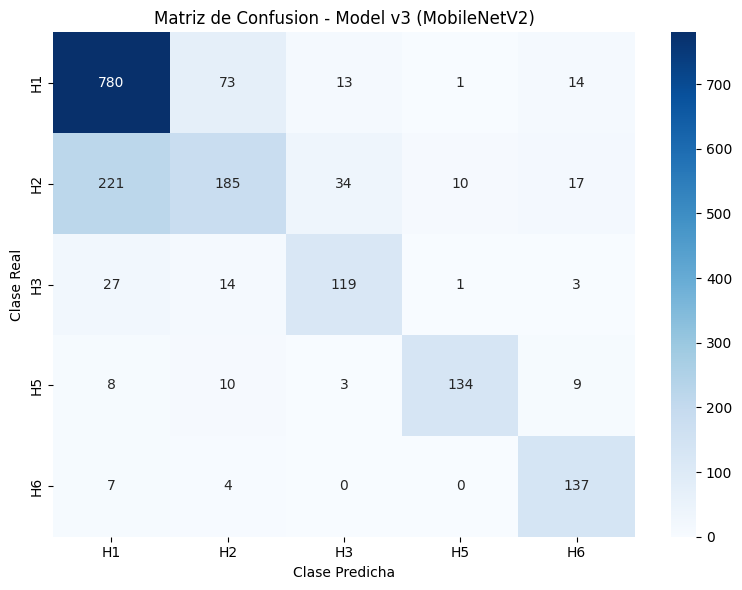

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion matrix
cm_v3 = confusion_matrix(true_classes, predicted_classes_p1)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_v3, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusion - Model v3 (MobileNetV2)')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()

In [ ]:
model_v3.save('/content/drive/MyDrive/TC3002/model_v3_224_phase1.keras')
print("Model v3 Phase 1 saved")

Model v3 Phase 1 saved


## Conclusions

- Transfer learning with MobileNetV2 significantly outperformed the custom CNN (74.29% vs 63%),
confirming the approach used in the reference paper [1]
- The most critical factor was using the **correct preprocessing** (`preprocess_input` instead of `rescale=1./255`).
This single change resolved the domain mismatch between how MobileNetV2 was trained and how we were feeding it data,
producing a large accuracy jump
- Increasing the image size to **224×224** allowed MobileNetV2 to use its full feature extraction capacity,
contributing to better performance on visually similar fungi classes
- Class weights were maintained from v2 and continued to be effective — the minority classes H3, H5, and H6
reached F1-scores of 0.71, 0.86, and 0.84 respectively, compared to below 0.10 in v1
- EarlyStopping triggered at epoch 14, restoring best weights from epoch 9 (val_loss: 0.6273)
- H2 remains the most difficult class (F1: 0.49) due to its visual similarity to H1,
both being types of Hyaline Hyphae under the microscope
- The gap to the state-of-the-art (93%) is explained by the paper using EfficientNet-B3 with full fine-tuning —
a more powerful architecture trained on the same ImageNet features but with more parameters and deeper feature extraction

## References

- [1] Korkmaz, A. F., Ekinci, F., Kumru, E., Aydogan, A., Kaymak, H. S., Sevindik, M., Guzel, M. S., & Akata, I. (2026).
Explainable deep learning ensemble framework for accurate classification of wild poisonous mushroom species.
*BMC Biotechnology*, 26, 11. https://doi.org/10.1186/s12896-025-01092-z

In [59]:
from tensorflow.keras.models import load_model

model_v3 = load_model('/content/drive/MyDrive/TC3002/model_v3_224_phase1.keras')
print("Phase 1 loaded - 74.29%")

Phase 1 loaded - 74.29%


Saving 11.jpg to 11.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


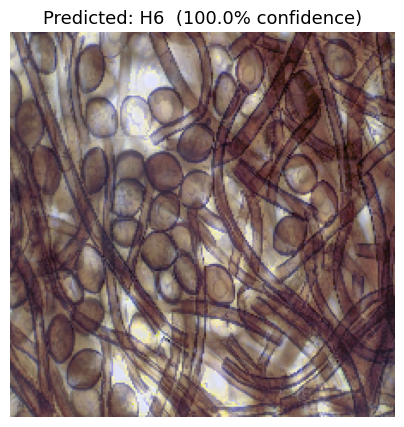


Probabilities per class:
  H1: 0.00%
  H2: 0.00%
  H3: 0.00%
  H5: 0.00%
  H6: 100.00%


In [68]:
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Preprocess (224x224, MobileNetV2 preprocessing)
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = preprocess_input(img_array)          # -1 to 1 range
img_array = np.expand_dims(img_array, axis=0)   # batch dimension

# Predict
predictions = model_v3.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

# Result
plt.figure(figsize=(5, 5))
plt.imshow(image.load_img(img_path, target_size=(224, 224)))
plt.title(f'Predicted: {predicted_class}  ({confidence:.1f}% confidence)', fontsize=13)
plt.axis('off')
plt.show()

print(f"\nProbabilities per class:")
for i, cls in enumerate(class_names):
    print(f"  {cls}: {predictions[0][i]*100:.2f}%")